# Q1

## (a)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [69]:
def polynomial_feature_map(X, k):
    """
    Input:
    - X: An [m, ] np array with m data points
    - k: number of polynomial basis {phi_1 = 1, phi_2 = x, phi_3 = x^2, phi_4 = x^3, ..., phi_k = x^{k-1}}

    Output:
    - Phi: A mapped feature data set
    """
    feature_map = [lambda x, y=sub_k: x**y for sub_k in range(k)]
    Phi = np.array([[func(x) for func in feature_map] for x in X])
    return Phi


def plain_linear_regression(Phi, y):
    """
    Input:
    - Phi: An [m, k] np array with m data points and k features
    - y: A [m,] np array of data

    Output:
    - w: A [k, ] np array minimising (Phi w - y)^T (Phi w - y)
    - mse: a scalar which calculates mean square errors
    """
    m, k = Phi.shape
    assert len(y) == m, "Length of dataset does not match."
    if k > m:
        # Use dual form Phi^T (Phi Phi^T)^{-1} y
        alpha = np.linalg.solve(Phi @ Phi.T, y)
        w = Phi.T @ alpha
    else:
        # Use primal form (Phi^T Phi)^{-1} Phi^T y
        w = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
    mse = np.linalg.norm(y - Phi @ w)**2 / m
    return w, mse

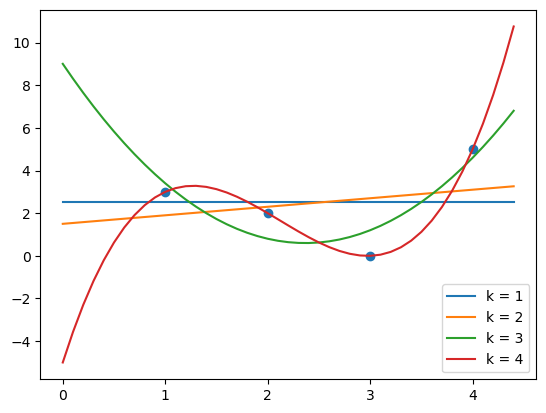

In [70]:
X = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([3.0, 2.0, 0.0, 5.0])
ks = [1, 2, 3, 4]
Ws = []
MSEs = []
plt.figure()
plt.scatter(X, y)
for k in ks:
    Phi = polynomial_feature_map(X, k)
    w, mse = plain_linear_regression(Phi, y)
    Ws.append(w)
    MSEs.append(mse)
    xs = np.arange(0.0, 4.5, 0.1)
    Phi_xs = polynomial_feature_map(xs, k)
    ys = Phi_xs @ w
    plt.plot(xs, ys, linestyle='-', label=f'k = {k}')
plt.legend()
plt.show()



## (b)

In [71]:
from sympy import symbols, Poly, latex
from IPython.display import display, Math

x_symbol = symbols('x')

for i, k in enumerate(ks[:-1]):
    list_of_coefficients = Ws[i].tolist()
    list_of_coefficients.reverse()
    list_of_coefficients = [round(c, 2) for c in list_of_coefficients]
    polynomial = Poly(list_of_coefficients, x_symbol)
    polynomial_expr = polynomial.as_expr()
    display(Math(rf'k = {k}\\' + r'\hat{y} =' + latex(polynomial_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## (c)

In [85]:
import pandas as pd
from IPython.display import HTML
df = pd.DataFrame({'k' : ks, 'MSE' : MSEs})
df['MSE'] = df['MSE'].map('{:g}'.format)
print(df.to_latex(index=False))

\begin{tabular}{rl}
\toprule
k & MSE \\
\midrule
1 & 3.25 \\
2 & 3.05 \\
3 & 0.8 \\
4 & 1.90115e-28 \\
\bottomrule
\end{tabular}



# Q2

## (a)

In [7]:
def g_sigma(x, sigma):
    """
    Evaluate g_sigma(x) = sin^2(2pi x) + eps
    Input:
    - x: input of the function
    - sigma: eps is sampled from N(0, sigma^2)
    """
    g = np.sin(2.0 * np.pi * x)**2 + np.random.normal(0, sigma, x.shape)
    return g

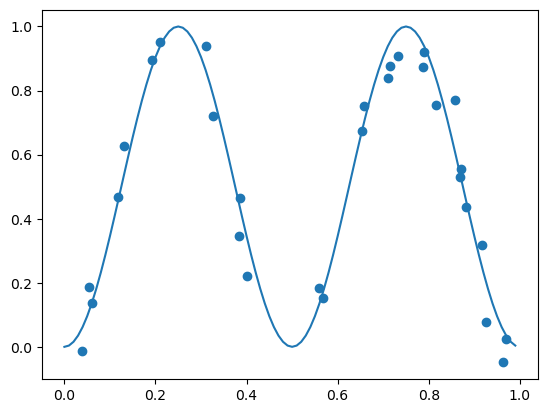

In [45]:
np.random.seed(223)
random_xs = np.random.uniform(0, 1, 30)
xs = np.arange(0, 1, 0.01)
sigma = 0.07
gs = g_sigma(random_xs, sigma)
sins = g_sigma(xs, 0)
plt.figure()
plt.scatter(random_xs, gs)
plt.plot(xs, sins, linestyle='-')
plt.show()

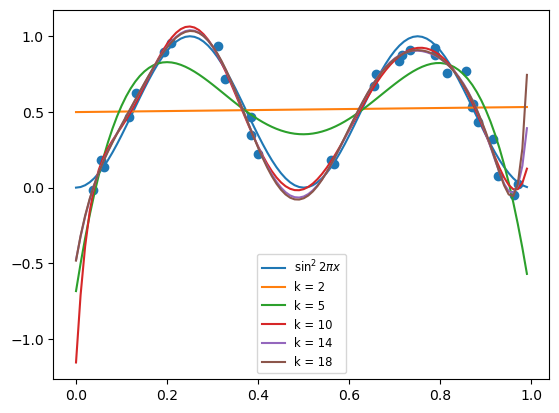

In [46]:
ks = [2, 5, 10, 14, 18]
Ws = []
MSEs = []
plt.figure()
plt.scatter(random_xs, gs)
plt.plot(xs, sins, linestyle='-', label=r'$\sin^2{2\pi x}$')
for k in ks:
    Phi = polynomial_feature_map(random_xs, k)
    w, mse = plain_linear_regression(Phi, gs)
    Ws.append(w)
    MSEs.append(mse)
    Phi_xs = polynomial_feature_map(xs, k)
    ys = Phi_xs @ w
    plt.plot(xs, ys, linestyle='-', label=f'k = {k}')
plt.legend(fontsize='small')
plt.show()

## (b)

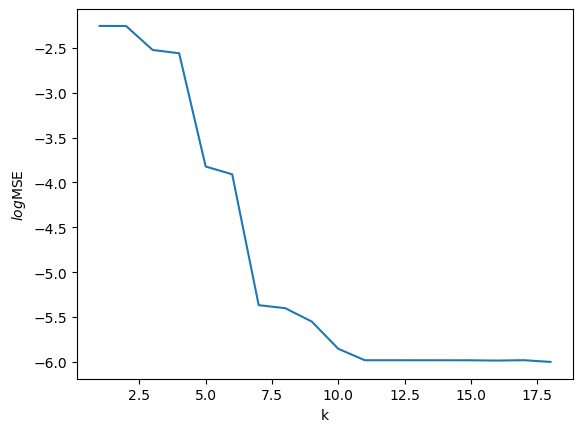

In [50]:
ks = list(range(1, 19))
gWs = []
MSEs = []
for k in ks:
    Phi = polynomial_feature_map(random_xs, k)
    w, mse = plain_linear_regression(Phi, gs)
    gWs.append(w)
    MSEs.append(mse)
log_mses = np.log(np.array(MSEs))
plt.figure()
plt.plot(ks, log_mses)
plt.xlabel('k')
plt.ylabel('$log$MSE')
plt.show()

## (c)

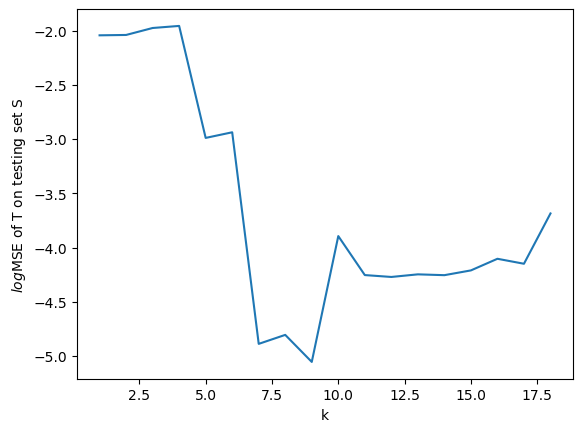

In [51]:
np.random.seed(2)
Ts = np.random.uniform(0, 1, 1000)
gTs = g_sigma(Ts, 0.07)
Cross_MSEs = np.array([np.average((gTs - polynomial_feature_map(Ts, k) @ w)**2) for k, w in zip(ks, gWs)])
plt.figure()
plt.plot(ks, np.log(Cross_MSEs))
plt.xlabel('k')
plt.ylabel('$log$MSE of T on testing set S')
plt.show()

## (d)

In [52]:
sum_training_MSEs = np.zeros(len(ks))
sum_testing_MSEs = np.zeros(len(ks))

for _ in range(100):
    this_Ss = np.random.uniform(0, 1, 30)
    this_gSs = g_sigma(this_Ss, 0.07)
    this_Ts = np.random.uniform(0, 1, 1000)
    this_gTs = g_sigma(this_Ts, 0.07)
    for i, k in enumerate(ks):
        Phi = polynomial_feature_map(this_Ss, k)
        w, mse = plain_linear_regression(Phi, this_gSs)
        sum_training_MSEs[i] += mse
        testing_mse = np.linalg.norm(this_gTs - polynomial_feature_map(this_Ts, k) @ w)**2 / len(this_Ts)
        sum_testing_MSEs[i] += testing_mse
sum_training_MSEs /= 100.0
sum_testing_MSEs /= 100.0

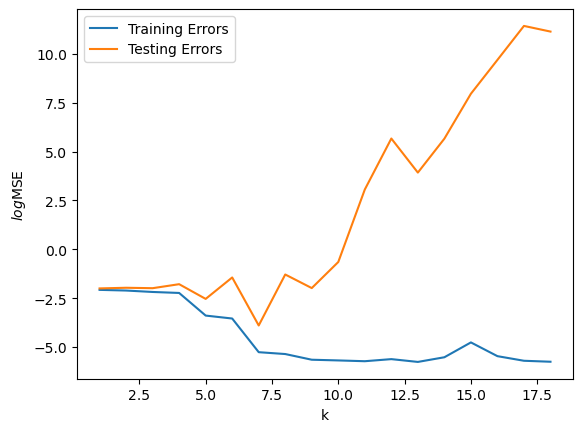

In [53]:
plt.figure()
plt.plot(ks, np.log(sum_training_MSEs), label='Training Errors')
plt.plot(ks, np.log(sum_testing_MSEs), label='Testing Errors')
plt.xlabel('k')
plt.ylabel('$log$MSE')
plt.legend()
plt.show()

# Q3

In [54]:
def sine_feature_map(X, k):
    """
    Input:
    - X: An [m, ] np array with m data points
    - k: number of sine basis {sin(1 pi x), sin(2 pi x), ..., sin(k pi x)}

    Output:
    - Phi: A mapped feature data set
    """
    feature_map = [lambda x, y=sub_k: np.sin((y+1) * np.pi * x) for sub_k in range(k)]
    Phi = np.array([[func(x) for func in feature_map] for x in X])
    return Phi

In [55]:
sum_training_MSEs = np.zeros(len(ks))
sum_testing_MSEs = np.zeros(len(ks))
first_training_MSEs = np.zeros(len(ks))
first_testing_MSEs = np.zeros(len(ks))
for _ in range(100):
    this_Ss = np.random.uniform(0, 1, 30)
    this_gSs = g_sigma(this_Ss, 0.07)
    this_Ts = np.random.uniform(0, 1, 1000)
    this_gTs = g_sigma(this_Ts, 0.07)
    for i, k in enumerate(ks):
        Phi = sine_feature_map(this_Ss, k)
        w, mse = plain_linear_regression(Phi, this_gSs)
        sum_training_MSEs[i] += mse
        testing_mse = np.linalg.norm(this_gTs - sine_feature_map(this_Ts, k) @ w)**2 / len(this_Ts)
        sum_testing_MSEs[i] += testing_mse
        if _ == 0:
            first_training_MSEs[i] += mse
            first_testing_MSEs[i] += testing_mse
sum_training_MSEs /= 100.0
sum_testing_MSEs /= 100.0

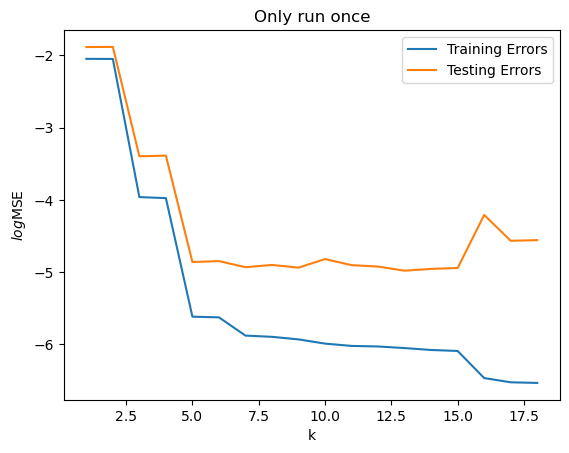

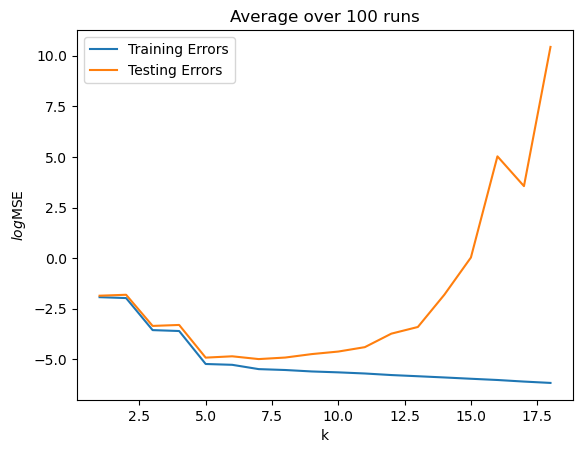

In [56]:
plt.figure()
plt.plot(ks, np.log(first_training_MSEs), label='Training Errors')
plt.plot(ks, np.log(first_testing_MSEs), label='Testing Errors')
plt.xlabel('k')
plt.ylabel('$log$MSE')
plt.title('Only run once')
plt.legend()
plt.show()

plt.figure()
plt.plot(ks, np.log(sum_training_MSEs), label='Training Errors')
plt.plot(ks, np.log(sum_testing_MSEs), label='Testing Errors')
plt.xlabel('k')
plt.ylabel('$log$MSE')
plt.title('Average over 100 runs')
plt.legend()
plt.show()

# Q4

In [61]:
boston_data = pd.read_csv('Boston-filtered.csv')

In [62]:
from sklearn.model_selection import train_test_split
from collections import defaultdict
num_of_runs = 20
mse_train_dict = defaultdict(list)
mse_test_dict = defaultdict(list)
for _ in range(num_of_runs):
    training_set, testing_set = train_test_split(boston_data, test_size=1.0/3.0)
    training_x = training_set.drop('MEDV', axis=1)
    training_y = training_set['MEDV']
    testing_x = testing_set.drop('MEDV', axis=1)
    testing_y = testing_set['MEDV']
    train_size = len(training_set)
    test_size = len(testing_set)
    train_ones = np.ones(train_size)
    test_ones = np.ones(test_size)
    w_const, mse_const = plain_linear_regression(train_ones[:, None], training_y.to_numpy())
    mse_const_testing = np.linalg.norm(testing_y.to_numpy() - test_ones[:, None] @ w_const)**2 / test_size
    mse_train_dict['CONST'].append(mse_const)
    mse_test_dict['CONST'].append(mse_const_testing)

    for column in training_x:
        this_x = training_set[column]
        this_testing_x = testing_set[column]
        Phi = polynomial_feature_map(this_x.to_numpy(), 2)
        Phi_test = polynomial_feature_map(this_testing_x.to_numpy(), 2)
        w_single, mse_single = plain_linear_regression(Phi, training_y.to_numpy())
        mse_single_testing = np.linalg.norm(testing_y.to_numpy() - Phi_test @ w_single)**2 / test_size
        mse_train_dict[column].append(mse_single)
        mse_test_dict[column].append(mse_single_testing)
    
    training_x_with_bias = np.concatenate((training_x.to_numpy(), train_ones[:, None]), axis=1)
    testing_x_with_bias = np.concatenate((testing_x.to_numpy(), test_ones[:, None]), axis=1)
    w_all, mse_all = plain_linear_regression(training_x_with_bias, training_y.to_numpy())
    mse_testing_all = np.linalg.norm(testing_y.to_numpy() - testing_x_with_bias @ w_all)**2 / test_size
    mse_train_dict['ALL'].append(mse_all)
    mse_test_dict['ALL'].append(mse_testing_all)
        
print(f'Training MSE for constant function is {np.average(mse_train_dict["CONST"]):.2f}, testing MSE is {np.average(mse_test_dict["CONST"]):.2f}')
for column in training_x:
    print(f'Training MSE for single attribute {column} is {np.average(mse_train_dict[column]):.2f}, testing MSE is {np.average(mse_test_dict[column]):.2f}')
print(f'Training MSE for all features is {np.average(mse_train_dict['ALL']):.2f}, testing MSE is {np.average(mse_test_dict['ALL']):.2f}')


Training MSE for constant function is 84.07, testing MSE is 85.39
Training MSE for single attribute CRIM is 70.94, testing MSE is 74.00
Training MSE for single attribute  ZN  is 73.07, testing MSE is 74.64
Training MSE for single attribute INDUS  is 64.58, testing MSE is 65.26
Training MSE for single attribute CHAS is 81.29, testing MSE is 83.53
Training MSE for single attribute NOX is 68.63, testing MSE is 70.09
Training MSE for single attribute RM is 41.74, testing MSE is 47.92
Training MSE for single attribute AGE is 71.94, testing MSE is 73.72
Training MSE for single attribute DIS is 78.76, testing MSE is 80.32
Training MSE for single attribute RAD is 71.38, testing MSE is 74.06
Training MSE for single attribute TAX is 65.19, testing MSE is 67.76
Training MSE for single attribute PTRATIO is 61.28, testing MSE is 65.80
Training MSE for single attribute LSTAT is 38.01, testing MSE is 39.74
Training MSE for all features is 21.17, testing MSE is 26.56


Using a const function to do the regression is effectively calculating $$w^* = \arg\min_w \sum_i^m \left(y_i - w\right)^2 = \frac{1}{m}\sum_i^m y_i$$

$w^*$ is effectively the mean estimate of $\{y_i\}$.

From the output above, we can see the regression on all features outperforms any other single attribute or const function.

# Q5

In [63]:
def log_Gaussian_kernel(sigma, x_i, x_j):
    """
    We implement log Gaussian kernel log K(x_i, x_j) = -||x_i - x_j||^2 / (2 sigma^2)

    Input:
    sigma: a scalar for the tightness of Gaussian kernel
    x_i, x_j: [k,] np arrays

    Output:
    log kernel: a scalar
    """
    assert len(x_i) == len(x_j), "Size of x_i and x_j does not match"
    log_kernel = np.linalg.norm(x_i - x_j)**2 / (-2 * sigma**2)
    return log_kernel

def vectorised_kernel_ridge_regression(X, y, sigmas, gammas, X_test=None, y_test=None):
    """
    Vectorised Kernelised ridge regression. We get alpha^* = argmin 1/l ||K alpha - y||^2 + gamma alpha^T K alpha
    for different sigmas and gammas

    Input:
    X: An [l, d] np array as training data set
    y: An [l,] np array as targeting data
    sigmas: An [n, ] sigmas used in gaussian kernel
    gammas: An [m, ] used in ridge regression
    X_test: If not None, a [k, d] as testing data set
    y_test: If not None, a [k, ] as testing data set

    Output:
    alphas: An [n, l, m] np array
    mse: An [n, m] np array for mean square error
    mse_test: If X_test and y_test are supplied, calculate MSE on test set, otherwise None
    """
    l = X.shape[0]
    n = len(sigmas)
    assert len(y) == l, "Size of training data does not match with targeting data"
    # log K0 is in [l, l] with sigma = 1
    log_K0 = np.array([[log_Gaussian_kernel(1.0, X[i, :], X[j, :]) for j in range(l)] for i in range(l)])
    # K_sigmas is in [n, l, l]
    K_sigmas = np.array([np.exp(log_K0 / sigma**2) for sigma in sigmas])
    Il = np.eye(l)
    alphas = np.array([np.array([np.linalg.solve(K_sigma + gamma * Il, y[:, None]).flatten() for gamma in gammas]).T for K_sigma in K_sigmas])
    mse = np.array([np.linalg.norm(K_sigmas[iSigma] @ alphas[iSigma] - y[:, None], axis=0)**2 / l for iSigma in range(n)])

    if isinstance(X_test, np.ndarray) and isinstance(y_test, np.ndarray):
        k = X_test.shape[0]
        assert len(y_test) == k, "Size of testing data does not match."
        # log_K0_test is in [l, k] with sigma = 1
        log_K0_test = np.array([[log_Gaussian_kernel(1, X[i, :], X_test[sub_k, :]) for sub_k in range(k)] for i in range(l)])
        # K_sigmas_test is in [n, l, k]
        K_sigmas_test = np.array([np.exp(log_K0_test / sigma**2) for sigma in sigmas])
        mse_test = np.array([np.linalg.norm(K_sigmas_test[iSigma].T @ alphas[iSigma] - y_test[:, None], axis=0)**2 / k for iSigma in range(n)])
    else:
        mse_test = None
    return alphas, mse, mse_test


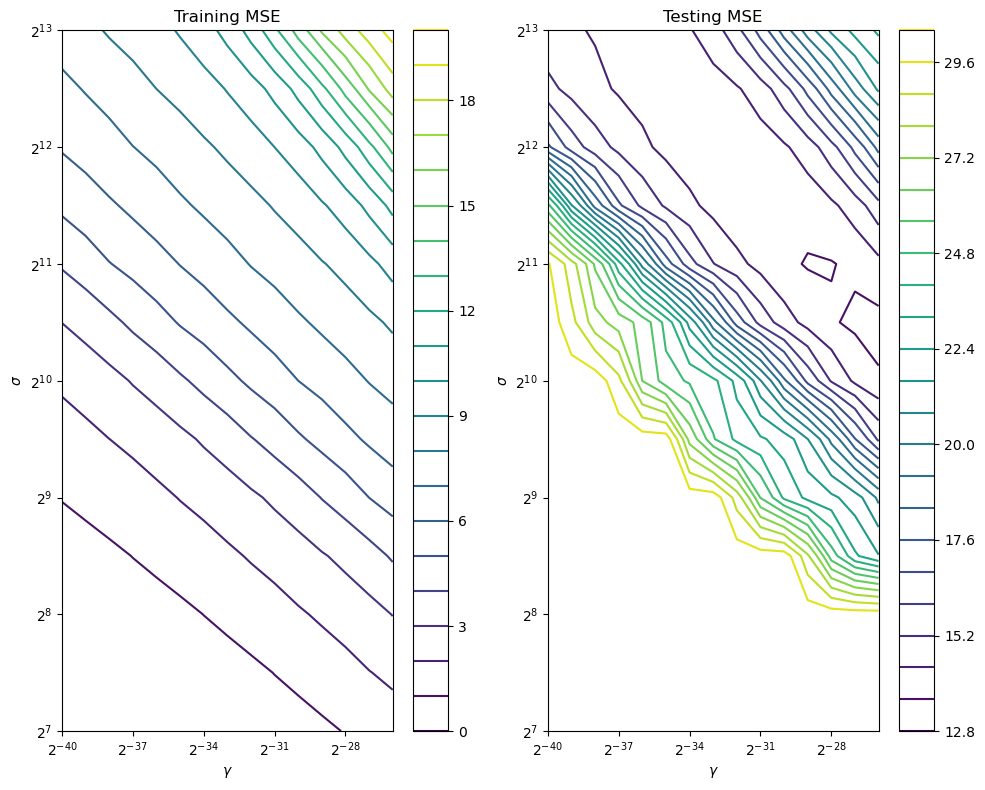

MSE on training set is 8.52. MSE on testing set is 12.73.
Best parameters are:


<IPython.core.display.Math object>

In [67]:
from sklearn.model_selection import train_test_split, KFold
np.random.seed(10)
num_of_runs = 20
gammas = np.array([2**i for i in range(-40, -25)])
sigmas = np.array([2**i for i in np.arange(7, 13.5, 0.5)])

for _ in range(num_of_runs):
    training_set, testing_set = train_test_split(boston_data, test_size=1.0/3.0)
    MSE_sigma_gamma_training = np.zeros((len(sigmas), len(gammas)))
    MSE_sigma_gamma_testing = np.zeros((len(sigmas), len(gammas)))
    num_splits = 5
    Kf = KFold(n_splits=num_splits)
    for i, (train_index, test_index) in enumerate(Kf.split(training_set)):
        sub_fold_training_set = training_set.iloc[train_index]
        sub_fold_testing_set = training_set.iloc[test_index]
        training_x = sub_fold_training_set.drop('MEDV', axis=1)
        training_y = sub_fold_training_set['MEDV']
        testing_x = sub_fold_testing_set.drop('MEDV', axis=1)
        testing_y = sub_fold_testing_set['MEDV']
        train_size = len(training_y)
        test_size = len(testing_y)
        this_alphas, this_mse, this_mse_test = vectorised_kernel_ridge_regression(training_x.to_numpy(), training_y.to_numpy(), sigmas, gammas, testing_x.to_numpy(), testing_y.to_numpy())
        MSE_sigma_gamma_training += this_mse
        MSE_sigma_gamma_testing += this_mse_test
    MSE_sigma_gamma_training /= num_splits
    MSE_sigma_gamma_testing /= num_splits

    min_iSigma, min_iGamma = np.unravel_index(MSE_sigma_gamma_testing.argmin(), MSE_sigma_gamma_testing.shape)
    argmin_gamma = gammas[min_iGamma]
    argmin_sigma = sigmas[min_iSigma]
    whole_training_x = training_set.drop('MEDV', axis=1)
    whole_training_y = training_set['MEDV']
    whole_testing_x = testing_set.drop('MEDV', axis=1)
    whole_testing_y = testing_set['MEDV']
    alpha, mse, mse_test = vectorised_kernel_ridge_regression(whole_training_x.to_numpy(), whole_training_y.to_numpy(), np.array([argmin_sigma]), np.array([argmin_gamma]), whole_testing_x.to_numpy(), whole_testing_y.to_numpy())
    mse_train_dict['KERNEL'].append(mse[0,0])
    mse_test_dict['KERNEL'].append(mse_test[0,0])
    if _ == 0:
        fig, axs = plt.subplots(1, 2, figsize=(10,8))
        contour1 = axs[0].contour(gammas, sigmas, MSE_sigma_gamma_training, levels=20, cmap='viridis')
        fig.colorbar(contour1, ax=axs[0])
        axs[0].set_xlabel(r'$\gamma$')
        axs[0].set_ylabel(r'$\sigma$')
        axs[0].set_xscale('log', base=2)
        axs[0].set_yscale('log', base=2)
        axs[0].set_title('Training MSE')

        contour2 = axs[1].contour(gammas, sigmas, np.minimum(30.0, MSE_sigma_gamma_testing), levels=20, cmap='viridis')
        fig.colorbar(contour2, ax=axs[1])
        axs[1].set_xlabel(r'$\gamma$')
        axs[1].set_ylabel(r'$\sigma$')
        axs[1].set_xscale('log', base=2)
        axs[1].set_yscale('log', base=2)
        axs[1].set_title('Testing MSE')
        plt.tight_layout()
        plt.show()

        print(rf'MSE on training set is {mse[0,0]:.2f}. MSE on testing set is {mse_test[0,0]:.2f}.')
        print('Best parameters are:')
        display(Math(rf'\gamma: 2^{{{np.log2(argmin_gamma)}}}, \sigma: 2^{{{np.log2(argmin_sigma)}}}.'))


In [84]:
methods = []
train_summary = []
test_summary = []
for method, train_mse in mse_train_dict.items():
    test_mse = mse_test_dict[method]
    if method == 'CONST':
        methods.append('Naive Regression')
    elif method == 'ALL':
        methods.append('Linear Regression (all attributes)')
    elif method == 'KERNEL':
        methods.append('Kernel Ridge Regression')
    else:
        methods.append(f'Linear Regression (attribute {method})')
    train_summary.append(f'{np.mean(train_mse):.2f} \u00B1 {np.std(train_mse):.2f}')
    test_summary.append(f'{np.mean(test_mse):.2f} \u00B1 {np.std(test_mse):.2f}')
summary_df = pd.DataFrame({'Method' : methods, 'MSE train' : train_summary, 'MSE test' : test_summary})
print(summary_df.to_latex(index=False))

\begin{tabular}{lll}
\toprule
Method & MSE train & MSE test \\
\midrule
Naive Regression & 84.07 ± 6.20 & 85.39 ± 12.41 \\
Linear Regression (attribute CRIM) & 70.94 ± 6.00 & 74.00 ± 12.42 \\
Linear Regression (attribute  ZN ) & 73.07 ± 5.48 & 74.64 ± 10.98 \\
Linear Regression (attribute INDUS ) & 64.58 ± 5.39 & 65.26 ± 10.96 \\
Linear Regression (attribute CHAS) & 81.29 ± 5.96 & 83.53 ± 12.08 \\
Linear Regression (attribute NOX) & 68.63 ± 5.69 & 70.09 ± 11.60 \\
Linear Regression (attribute RM) & 41.74 ± 3.98 & 47.92 ± 8.20 \\
Linear Regression (attribute AGE) & 71.94 ± 5.92 & 73.72 ± 11.85 \\
Linear Regression (attribute DIS) & 78.76 ± 6.20 & 80.32 ± 12.48 \\
Linear Regression (attribute RAD) & 71.38 ± 6.11 & 74.06 ± 12.46 \\
Linear Regression (attribute TAX) & 65.19 ± 5.86 & 67.76 ± 12.00 \\
Linear Regression (attribute PTRATIO) & 61.28 ± 4.76 & 65.80 ± 9.59 \\
Linear Regression (attribute LSTAT) & 38.01 ± 3.36 & 39.74 ± 6.78 \\
Linear Regression (all attributes) & 21.17 ± 2.30 & 2

# Q6

In [77]:
from collections import Counter
class knn_algo:
    """
    classification of points using k nearest neighbor algorithm. 
    It assumes only two groups and returns 0 if point belongs to group 0, else 1 (belongs to group 1).
    """
    def __init__(self, X, y):
        """
        Input:
        X: An [n, d] np array for training knn
        y: An [n, ] np array for labels. value is either 0 or 1
        """
        self._data = X
        self._n = X.shape[0]
        self._label = y
        assert len(y) == self._n, 'Size of labels does not match with data'

    def predict(self, X_new, k=3, training_points=None):
        """
        Do the prediction based on data and label with k nearest neighbours, default k = 3
        """
        # Calculate the distance
        m = X_new.shape[0]
        # create an [m, n] np array
        distances = np.array([np.linalg.norm(self._data - x[None, :], axis=1).T for x in X_new])
        if isinstance(training_points, int):
            training_points = np.array([training_points])
        elif isinstance(training_points, np.ndarray):
            pass
        else:
            training_points = np.array([self._n])
        assert max(training_points) <= self._n, f"Max {self._n} training points"
        k_sorted_distances = np.array([np.argpartition(distances[:, :this_training_point], k, axis=1)[:, :k] for this_training_point in training_points])
        k_nearest_ys = np.array([[self._label[arg] for arg in this_k_sorted_distances] for this_k_sorted_distances in k_sorted_distances])
        label_new = np.array([[Counter(lst.tolist()).most_common(1)[0][0] for lst in this_k_nearest_ys] for this_k_nearest_ys in k_nearest_ys])
        # label_new is in [size of num_training_points, size_of_testing_points]
        return label_new
    



In [59]:
np.random.seed(2024)
X = np.random.uniform(0, 1, (100, 2))
y = np.random.randint(0, 2, 100)
h_S = knn_algo(X, y)

In [60]:
from matplotlib.colors import ListedColormap
xx1, xx2 = np.meshgrid(np.arange(0, 1, 0.01),
                     np.arange(0, 1, 0.01))
meshgrids = np.c_[xx1.ravel(), xx2.ravel()]
Z = h_S.predict(meshgrids)
Z = Z.reshape(xx1.shape)

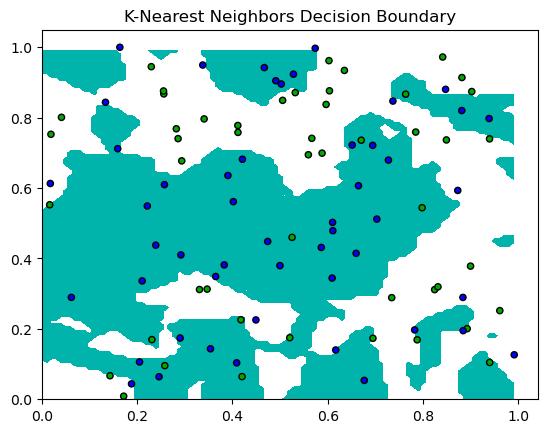

In [61]:
plt.figure()
cmap_light = ListedColormap(['#FFFFFF', '#00B4AB'])
cmap_bold = ListedColormap(['#00AA00', '#0000FF'])

plt.contourf(xx1, xx2, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
plt.title("K-Nearest Neighbors Decision Boundary")
plt.show()

# Q7

In [ ]:
def h_S_sampling(sample_size):
    """
    Sample a h from pH
    """
    X = np.random.uniform(0, 1, (sample_size, 2))
    y = np.random.randint(0, 2, sample_size)
    h_S = knn_algo(X, y)
    return h_S

def ph_dist_sampling(h_S, v, sample_size):
    """
    Sample from p_h where
    X is uniformly distributed from [0, 1]^2
    y is generated by flipping biased coin P(head) = 0.8. If head, y = h_S_v otherwise y is from unif(0, 1)
    """
    X = np.random.uniform(0, 1, (sample_size, 2))
    pre_y = np.random.choice([0, 1], sample_size, p=[0.2, 0.8])
    y_heads = h_S.predict(X[pre_y == 1], v).flatten()
    y_tails = np.random.randint(0, 2, len(pre_y[pre_y == 0]))
    y = np.zeros(len(pre_y))
    y[pre_y == 1] = y_heads
    y[pre_y == 0] = y_tails
    return X, y


In [ ]:
num_of_runs = 100
total_points = 5000
test_prop = 0.2
ks = np.arange(1, 50, 1)
np.random.seed(120)
gerrors = np.zeros(len(ks))
for _ in range(num_of_runs):
    # Sample a h
    this_hS = h_S_sampling(100)
    total_X, total_y = ph_dist_sampling(this_hS, 3, total_points)
    X_train, X_test, y_train, y_test = train_test_split(total_X, total_y, test_size=test_prop)
    this_knn = knn_algo(X_train, y_train)
    gerrors += np.array([sum(this_knn.predict(X_test, k).flatten() != y_test) for k in ks])

gerrors /= (num_of_runs * total_points * test_prop)

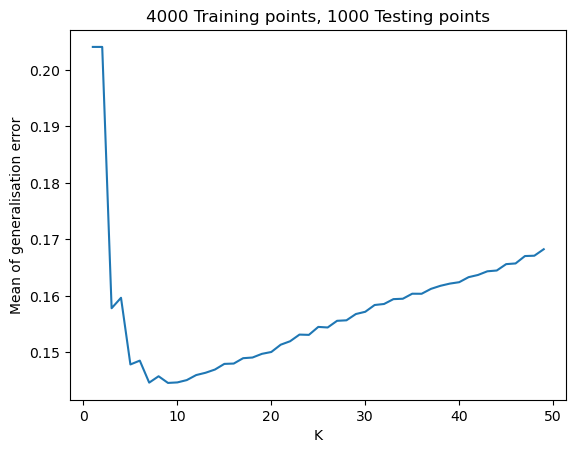

In [45]:
plt.figure()
plt.plot(ks, gerrors)
plt.xlabel('K')
plt.ylabel('Mean of generalisation error')
plt.title('4000 Training points, 1000 Testing points')
plt.show()

- The generalisation errors decrease first with k and then increase
- With increasing k, we have more neighbours for the majority votes and provide more accuracy
- But if k is too large, we potentially overfit the model, making generalisation error go up
- The generalisation errors go down with k quickly, but increase slowly
- For even k, it could have the undefined result with tie in majority vote

# Q8

In [70]:
num_of_runs = 100
total_points = np.arange(0, 4500, 500)
total_points[0] = 100
test_size = 1000
ks = np.arange(1, 50, 1)
np.random.seed(120)
best_ks = np.zeros(len(total_points))
for _ in range(num_of_runs):
    # Sample a h
    this_hS = h_S_sampling(100)
    max_total_points = max(total_points)
    total_X, total_y = ph_dist_sampling(this_hS, 3, max_total_points + test_size)
    X_train, X_test, y_train, y_test = train_test_split(total_X, total_y, test_size=test_size)
    this_knn = knn_algo(X_train, y_train)
    gerrors = np.array([np.sum(this_knn.predict(X_test, k, total_points) != y_test[None, :], axis=1).flatten() for k in ks]) / test_size
    best_k = ks[np.argmin(gerrors, axis=0)]
    best_ks += best_k

best_ks /= num_of_runs

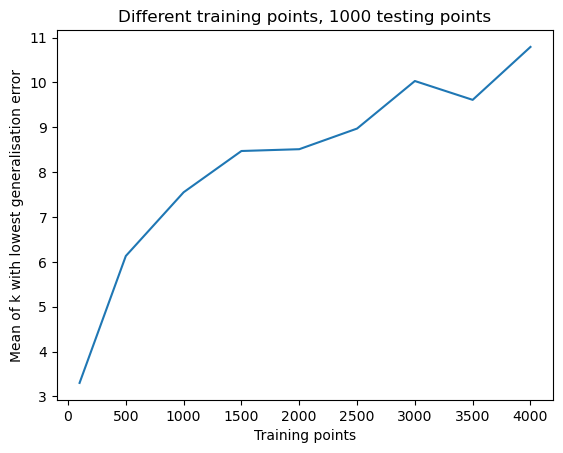

In [71]:
plt.figure()
plt.plot(total_points, best_ks)
plt.xlabel('Training points')
plt.ylabel('Mean of k with lowest generalisation error')
plt.title('Different training points, 1000 testing points')
plt.show()

- With more training points, there are more dense points in the optimal circle, and hence larger k.
- The relationship of optimal $k$ has roughly $\log$ relationship of training points.
- This corresponds to Bayesian information criterion: BIC = $-2\log(L) + p\log(N)$ where $\log(L)$ is the log likelihood of data, we have 1000 testing data for each $k$. We can assume this term is roughly same across different trainings. $N$ is the number of training points.
- BIC is derived from Laplace approximation of posterior distribution with prior knowledge. Here we assume the training data are uniformly distributed a priori.

### Corner case
- The corner case is when $k$ is even and there is a tie in the majority vote
- In my function I use `Counter(lst).most_common(1)[0][0]` which returns the most common one randomly if there is a tie.

# Q9

## (a)

$K_c$ is a kernel iff $c \geq 0$.
* When $c \geq 0$, we can define a feature map $\phi(\mathbf{x}) := [\sqrt{c}, x_1, \dots, x_n]$ such that $K_c(\mathbf{x}, \mathbf{z}) = \langle \phi(\mathbf{x}), \phi(\mathbf{z}) \rangle$.
* If $c < 0$, we now need to show given any vector a, $\mathbf{a}^{T} K_{c} \mathbf{a} \geq 0$ :

\begin{align*}
\mathbf{a}^{T} K_{c} \mathbf{a} & =\sum_{i}^{n} \sum_{j}^{n} a_{i} a_{j} K_{c}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) \\
& =\sum_{i} \sum_{j} a_{i} a_{j}\left(c+\boldsymbol{x}_{i}^{T} \boldsymbol{x}_{j}\right) \\
& =\sum_{i} \sum_{j} a_{i} a_{j} c+\sum_{i} \sum_{j} a_{i} a_{j} \boldsymbol{x}_{i}^{T} \boldsymbol{x}_{j} \\
& =\|\mathbf{a}\|^{2} c+\sum_{i} \sum_{j} a_{i} \boldsymbol{x}_{i}^{T} \boldsymbol{x}_{j} a_{j} \\
& =\|\mathbf{a}\|^{2} c+\left\|\sum_{i} a_{i} \boldsymbol{x}_{i}\right\|^{2}
\end{align*}

Here $\|\mathbf{a}\|^{2}$ and $\left\|\sum_{i} a_{i} \boldsymbol{x}_{i}\right\|^{2}$ are greater or equal to 0. It is guaranteed that $\mathbf{a}^{T} K_{c} \mathbf{a} \geq 0$ when $c \geq 0$. Notice when $c < 0$, there exists vector $\alpha$ s.t. $\mathbf{a}^{T} K_{c} \mathbf{a} < 0$, such $\alpha$ can be construct by a unit vector orthogonal to vector $x$.

## (b)

Recall in kernel regression we have
$$K_c\mathbf{\alpha} = \mathbf{y}$$
That is
$$c\mathbf{1}_n\mathbf{1}_n^\intercal\mathbf{\alpha} + K\mathbf{\alpha} = \mathbf{y}$$
where $K$ is the original state space of $\mathbf{x}$.

This is essentially acting as adding a bias to the regression, making the regression line have nonzero intercept and bring down the slope of the regression.

We can use a simple example to illustrate.

Suppose we only have 2 points: $(x_1, y_1)$ and $(x_2, y_2)$. We have:
$$
\begin{bmatrix}
c + x_1^2&c+x_1x_2\\
c+x_1x_2&c+x_2^2
\end{bmatrix}
\begin{bmatrix}
\alpha_1\\
\alpha_2
\end{bmatrix}
= 
\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}
$$

$$
\begin{cases}
c(\alpha_1 + \alpha_2) + x_1(\alpha_1x_1 + \alpha_2x_2) = y_1\\
c(\alpha_1 + \alpha_2) + x_2(\alpha_1x_1 + \alpha_2x_2) = y_2
\end{cases}
$$

$$f(x) = \alpha_1(c+x_1x)+\alpha_2(c+x_2x) = (\alpha_1x_1+\alpha_2x_2)x+c(\alpha_1+\alpha_2)$$

When $c$ increases, $\alpha_1$ and $\alpha_2$ decrease. So the slope decreases. On the other hand, $c(\alpha_1+\alpha_2)$ increases so the intercept increases.

# Q10

In kernel regression, we have:
$$\mathbf{\alpha} = K^{-1}\mathbf{y}$$
where $K$ is the gram kernel matrix of all data points.
$$f(\mathbf{t}) = \mathbf{\alpha}^\intercal K(\mathbf{x}, \mathbf{t}) = \mathbf{y}^\intercal K^{-1}K(\mathbf{x}, \mathbf{t})$$

Note $\mathbf{d} := K^{-1}K(\mathbf{x}, \mathbf{t})$ is a vector of size $n$ with $\mathbf{d}_i = \sum_j^n K^{-1}_{ij}\exp\left(-\beta||\mathbf{x}_j-\mathbf{t}||^2\right)$

If we would like to simulate a 1-Nearest Neighbour Classifier and without loss of generality we let $\mathbf{y}_i$ is the nearest point to $\mathbf{t}$. In that case:

$$\text{sign}(f(\mathbf{t})) = \text{sign}(\mathbf{y}^\intercal \mathbf{d}) = \text{sign}(\mathbf{y}_i\mathbf{d}_i + \sum_{j\neq i}^n \mathbf{y}_j\mathbf{d}_j )$$

A sufficient condition would be $\mathbf{d}_i > 0$ and $\mathbf{d}_i > \sum_{j\neq i}^n |\mathbf{d}_j|$

# Q11

## (a)

\begin{align*}
\varepsilon_{\rho_{i}}\left(f_{i}\right)=\int_{c \times \mathcal{Y}} \mathbb{I}\left\{f_{i}(x) \neq y\right\} d \rho_{i}(\{x, y\}) = 0
\end{align*}

\begin{align*}
\varepsilon_{\rho_{i}}(f)=\int_{c \times \mathcal{Y}} \mathbb{I}\{f(x) \neq y\} d \rho_{i}(\{x, y\}) \geqslant 0  
\end{align*}
where $f_{i} \in \mathcal{Y}^{c}$

The first equality holds because we define the distribution of $\rho_i$ in the way that $y = f_i(x)$

So we have
$$\varepsilon_{\rho_i}(f_i) = \inf_{f:\mathcal{X}\rightarrow\mathcal{Y}}\varepsilon_{\rho_i}(f) = 0$$

## (b)

$$
\mathbb{E}_{S \sim \rho_{i}^{n}} \varepsilon_{\rho_{i}}(A(S))=\sum_{j=1}^{k} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right) \times \frac{1}{k}
$$
because every data set $S_j$ is uniformly distributed in $C^n$.

Now we have:
\begin{align*}
\max _{i} \mathbb{E}_{s \sim \rho_{i}^{n}} \varepsilon_{\rho_{i}}(A(S)) 
& =\max _{i} \frac{1}{k} \sum_{j=1}^{k} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right) \\
\text { (max is larger than average) } & \geqslant \frac{1}{T} \sum_{i}^{T} \frac{1}{k} \sum_{j=1}^{k} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right) \\
& =\frac{1}{k} \sum_{j=1}^{k} \frac{1}{T} \sum_{i}^{T} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right) \\
& \geqslant \min _{j} \frac{1}{T} \sum_{i}^{T} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right)
\end{align*}

## (c)

\begin{align*}
\frac{1}{T} \sum_{i=1}^{T} \varepsilon_{p}\left(A\left(S_{j}^{i}\right)\right)
&= \frac{1}{T} \sum_{i=1}^{T} \int_{\mathcal{C} \times \mathcal{Y}} \mathbb{I}\left\{A\left(S_{j}^{i}\right) \neq y\right\} d \rho_{i} \\
& \geqslant \frac{1}{T} \sum_{i=1}^{T} \int_{R_{j} \times \mathcal{Y}} \mathbb{I}\left\{A\left(S_{j}^{i}\right)(v) \neq f_{i}(v)\right\} d \rho_{i}(\{(x, y)\}) \\
& =\frac{1}{T} \sum_{i=1}^{T} \sum_{m=1}^{p} \mathbb{I}\left\{A\left(S_{j}^{i}\right)\left(v_{m}\right) \neq f_{i}\left(v_{m}\right)\right\} \times \frac{1}{2 n} \\
& =\frac{1}{2} \frac{1}{n} \sum_{m=1}^{p} \frac{1}{T} \sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)\left(v_{m}\right) \neq f_{i}\left(v_{m}\right)\right\} \\
& \geqslant \frac{1}{2} \frac{1}{p} \sum_{m=1}^{p} \frac{1}{T} \sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)\left(v_{m}\right) \neq f_{i}\left(v_{m}\right)\right\} \\
& \geqslant \frac{1}{2} \min _{v \in R_{j}} \frac{1}{T} \sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)\left(v_{m}\right) \neq f_{i}\left(v_{m}\right)\right\}
\end{align*}

The second last inequality holds as we take $R_j$ as the subset of points of $C$ that do not belong to $S_j$. Since $|S_j|\leq n$ and $|C| = 2n$, we have $p \geq n$.

## (d)

If we partition $\mathcal{Y}^C$ into $\frac{T}{2}$ pairs $(f_i, f_{i^\prime})$ such that $f_i(x) \neq f_{i^\prime}(x)$ and we know $f(x)$ can only take binary values (either 1 or -1), we have the following:



$$
\mathbb{I}\left\{A\left(S_{j}^{i}\right)(v) \neq f_{i}(v)\right\}+\mathbb{I}\left\{A\left(S_{j}^{i^\prime}\right)(v) \neq f_{i^\prime}(v)\right\}=1
$$

as exclusively only one can be 1.

And we have $\frac{T}{2}$ pairs, we sum $\frac{T}{2}$ twice to get.

\begin{align*}
\sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)(v) \neq f_{i}(v)\right\}+\sum_{i=1}^{T}\mathbb{I}\left\{A\left(S_{j}^{i^\prime}\right)(v)\neq f_{i^\prime}(v) \right\} =T
\end{align*}
So 
$$
\frac{1}{T} \sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)(v) \neq f_{i}(v)\right\}=\frac{1}{2}
$$

## (e)

Let $x=1-z \in[0,1] \quad \mathbb{E}[x]=1-\mu$.
\begin{align*}
P(x>a)=P(1-z>a)=P(z<1-a)<\frac{1-\mu}{a} \\
P(z>1-a)=1-P(z<1-a)>\frac{a-1+\mu}{a}=\frac{\mu-(1-a)}{a} 
\end{align*}

## (f)

\begin{align*}
\varepsilon_{\rho}(A(s)) \leqslant 1 \int_{\mathcal{X} \times \mathcal{Y}} d \rho(x, y)=1
\end{align*}
Hence $\varepsilon_{p}(A(S)) \in[0,1]$

\begin{align*}
P_{s \sim \rho^{n}}\left(\varepsilon_{\rho}(A(S))>\frac{1}{8}\right) \geq \frac{\mathbb{E}\left[\varepsilon_{\rho}(A(S))\right]-\frac{1}{8}}{\frac{7}{8}}=\frac{8\mathbb{E}\left[\varepsilon_{\rho}(A(S))\right]-1}{7}
\end{align*}

\begin{align*}
\mathbb{E}\left[\varepsilon_{\rho}(A(S))\right] &=\frac{1}{T} \sum_{i=1}^T \mathbb{E}_{S \sim \rho_{i}^{n}} \varepsilon_{\rho_{i}}(A(S)) \geq \min _{j} \frac{1}{T} \sum_{i=1}^{T} \varepsilon_{\rho_{i}}\left(A\left(S_{j}^{i}\right)\right) \\
& \geq \frac{1}{2} \min _{v} \frac{1}{T} \sum_{i=1}^{T} \mathbb{I}\left\{A\left(S_{j}^{i}\right)(v) \neq f_{i}(v)\right\}
 =\frac{1}{4}
\end{align*}
Hence
\begin{align*}
    P_{S \sim \rho^{n}}\left(\varepsilon_\rho(A(S))>\frac{1}{8}\right) \geq \frac{1}{7}
\end{align*}

## (g)

We consider all possible functions in the space without any bias or assumptions.

1. For a function $f_{i}$ s.t. $\varepsilon_{\rho_{i}}\left(f_{i}\right)=0$ on a subset, the probability of that function mis-classification approximation error on the universe larger than $\frac{1}{8}$ is more than $\frac{1}{7}$.

2. With the previous setting, we have 
$$P_{S \sim \rho^{n}}\left(\varepsilon_\rho(A(S))\leq\epsilon\right) \geq 1-\delta$$
This implies
$$P_{S \sim \rho^{n}}\left(\varepsilon_\rho(A(S))>\epsilon\right) \leq \delta \quad \forall \epsilon, \delta \in (0, 1)$$
This contradicts to No-Free-Lunch theorem.

If we do not make any assumption of the function space, No-Free-Lunch theorem implies the space $\mathcal{Y}^{\mathcal{X}}$ of all functions $f: \mathcal{X} \rightarrow \mathcal{Y}$ is NOT learnable. Because of $P_{S \sim \rho^{n}}\left(\varepsilon_\rho(A(S))>\frac{1}{8} - 0\right) \geq \frac{1}{7}$, it states no matter how many countable $n$ we have, there is always non zero probability that approximation error is larger than 1/8.

3. 
- A certain algorithm can perform well on specific types of problems but may perform poorly on the others. We need to tailor the algorithms to the specific structure and characteristics of a given problem domain. We should try a variety of algorithms when approaching a new problem.
- There is no universal solver for all machine learning tasks. The model we train on the specific datasets could struggle to generalise well to out-of-sample datasets unless they share very similar characteristics. We should make sure training data and testing data have same characteristics.
- We need to make assumptions and narrow down the function space we would like to learn